# 第10回 word2vec 2: CBOWモデルの実装

**周辺語ベクトルを平均し、中心語を予測する**

## 到達目標

- CBOWの層構成と配列shapeを説明する
- 順伝播で中心語確率を求める
- 損失から埋め込み重みを更新する

## 今回の位置付け

- 前提: 周辺語はOne-hotで入力される
- 中心: 同じ入力重みを通して埋め込みへ変換する
- 接続: 周辺語ベクトルの平均から中心語を分類する


## 1. 用語の確認

| 用語 | 定義 | 混同しやすい点 |
|---|---|---|
| CBOWの実装 | Continuous Bag-of-Words | 第9回で比較した向きを、実際の重み更新まで書き下す |
| 中間層のサイズ | hidden size | 第9回で扱った層。この次元数が分散表現の次元になる |
| 交差エントロピー誤差 | 正解の語へ与えた確率が低いほど大きくなる損失 | -log(正解の確率) |
| エポック | 学習データ全体を1回学習し終える単位 | 損失の推移をエポックごとに記録して収束を見る |

実行の前に、この4語を自分の言葉で言い換えられるか確認します。


## 1b. 図とコードに出る用語

| 用語 | 正式名・読み | 使い方 |
|---|---|---|
| バッチサイズ | batch size | 一度にまとめて処理する件数。勾配はこの件数で平均する |
| 重みの初期化 | initialization | 小さな乱数で始める。すべて0だと全語が同じ更新になり学習しない |
| 逆伝播の実装 | backpropagation | 第4回で扱った手順を、CBOWの重みに対して書き下す |
| 学習率 1.0 | learning rate | 本演習は語彙7の小さな例のため大きめ。実データでは0.01前後 |
| 収束 | convergence | 損失がほとんど下がらなくなった状態。学習を止める目安になる |

説明なしに出てくる語をここで回収します。分からない語を残したまま先へ進みません。


## 1c. 図で見る仕組み

### CBOW: 周辺2語から中央語を当てる

CBOWの構造です。左にコンテキストの2語をone-hotで入れ、それぞれW_inを掛けて中間表現を作り、平均して一つのhにまとめます。平均するため語順は区別されません。次にW_outを掛けて語彙7語ぶんの得点を出し、softmaxで確率にします。正解の語の確率が高くなるように重みを更新します。

**入力2語・出力1語。学習後の W_in が単語の分散表現になる**

図はスライドの該当ページを参照します。


## 教科書の図: CBOWの順伝播

左右の周辺語を入力し、それぞれを入力側の重みで埋め込み、平均して中心語を予測する。図3-9から図3-12は、同じCBOWをネットワーク・レイヤ・具体例の順に表す。

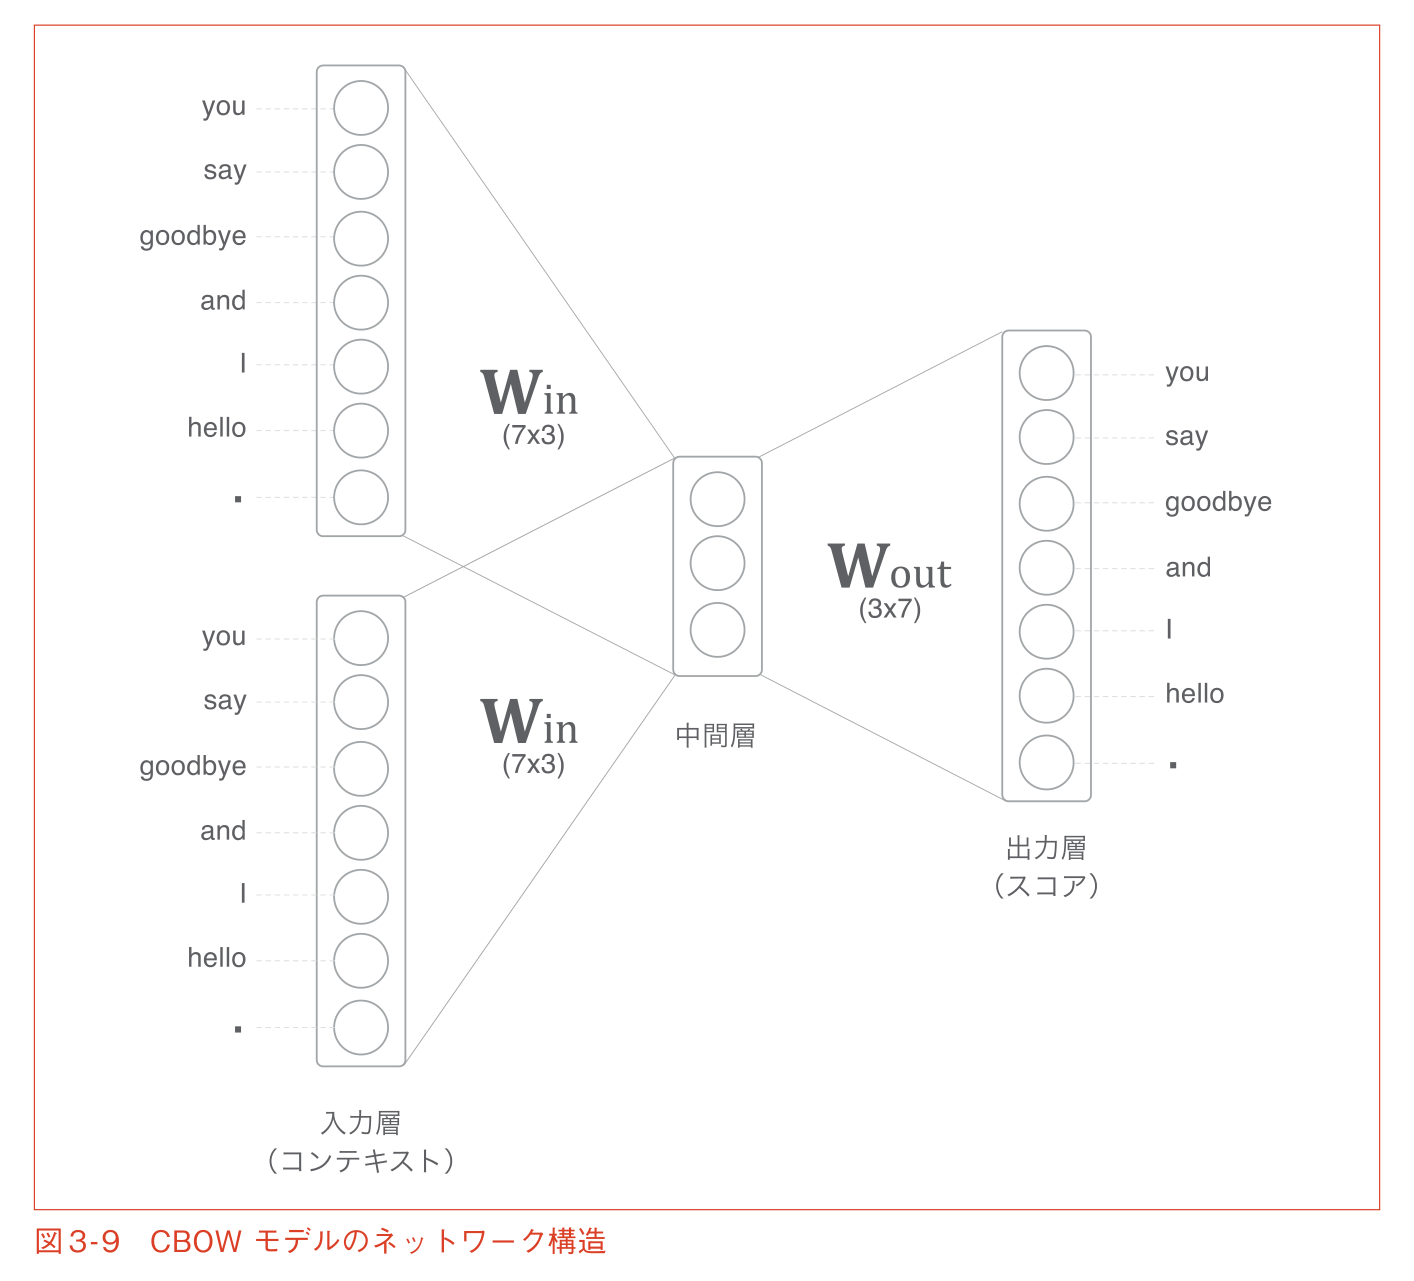

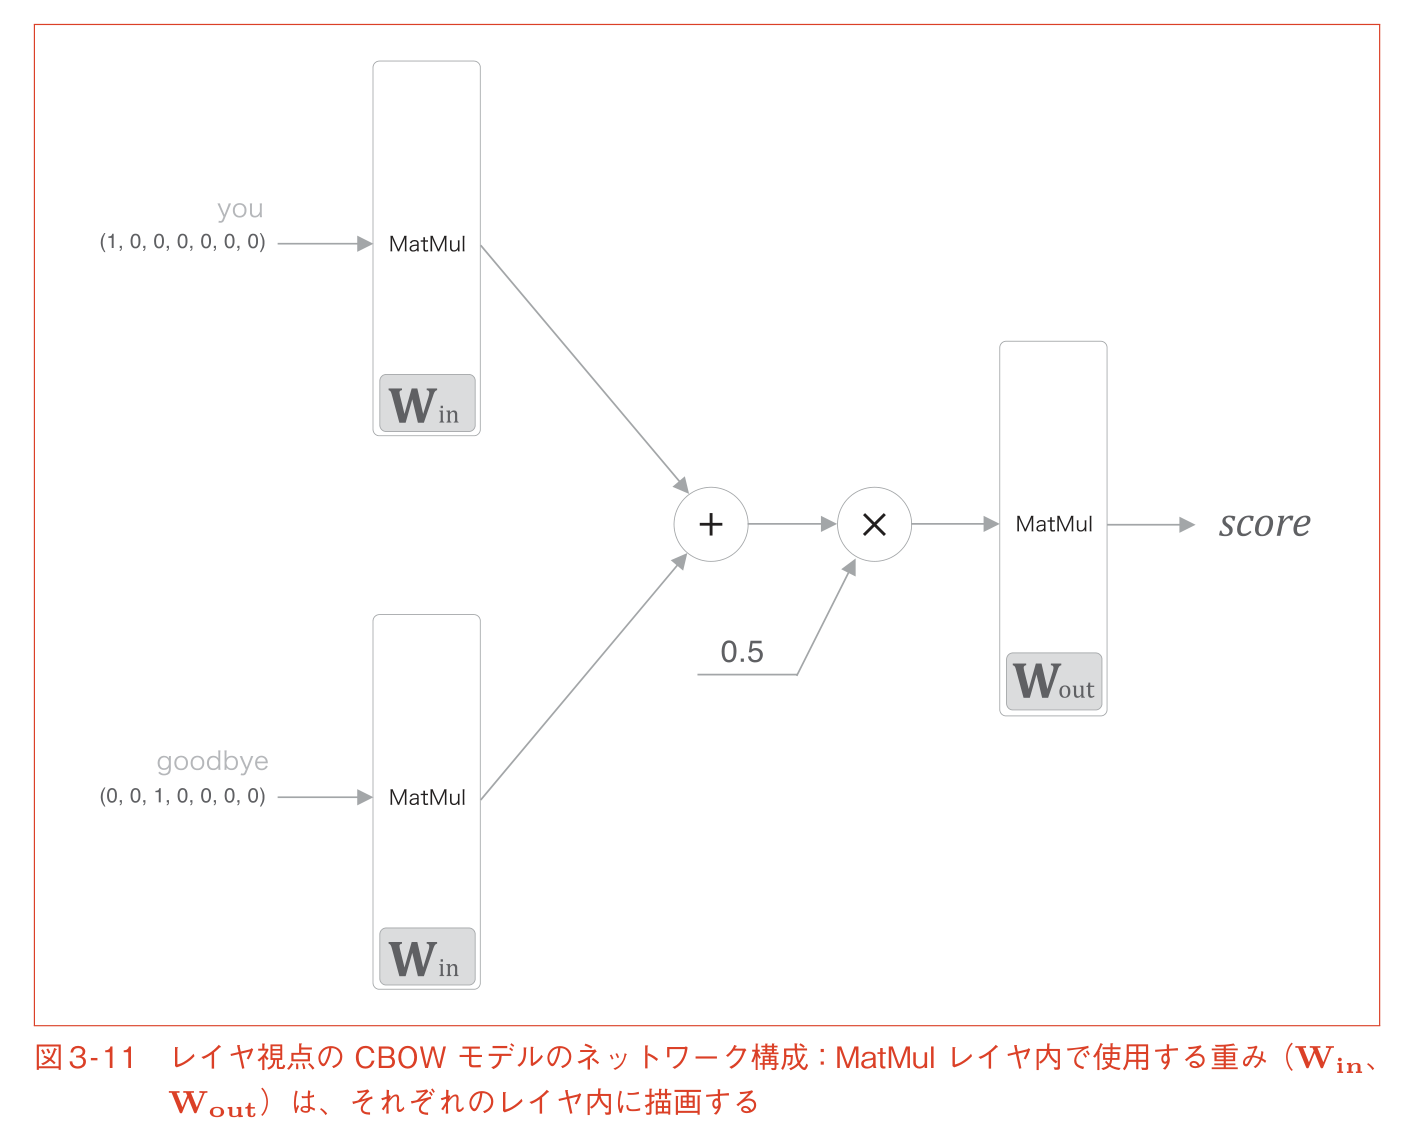

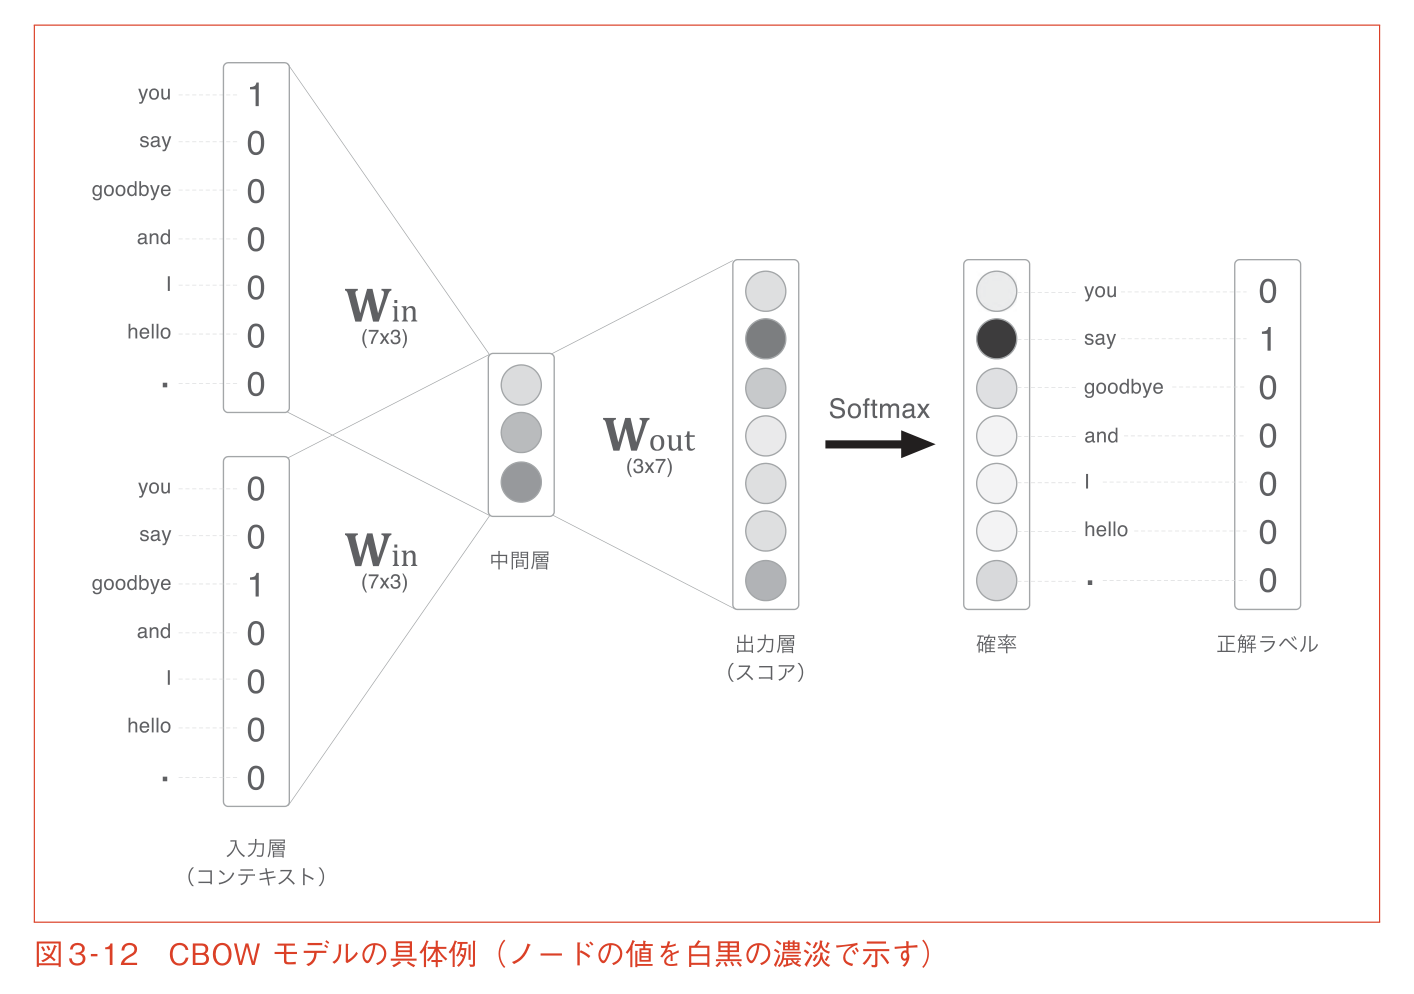

出典: 『ゼロから作るDeep Learning 2』第3章

## 2. 式とその意味

### CBOWの順伝播と勾配

```
h  = 0.5 * (c0 @ W_in + c1 @ W_in)
s  = h @ W_out
p  = softmax(s)
L  = -log( p[正解] )

dL/ds = p - t      (tは正解のone-hot)
```

**式の読み方**

- hは左右の平均でひとつにまとめた表現
- sは語彙数だけ並んだ得点
- 勾配は予測と正解の差になる

**なぜこの式か**

softmaxと交差エントロピーを別々に微分すると式は複雑になるが、合わせて微分すると p - t という引き算に収まる。だから実装では probability から正解の位置を1だけ引けばよい。第4回で確認した性質が、そのままここで効いている。


## 教科書の図: 正解との比較と損失

学習時は、周辺語から得た出力確率と正解の中心語を比較する。Softmaxと交差エントロピー誤差が、そのずれを損失として数値化する。

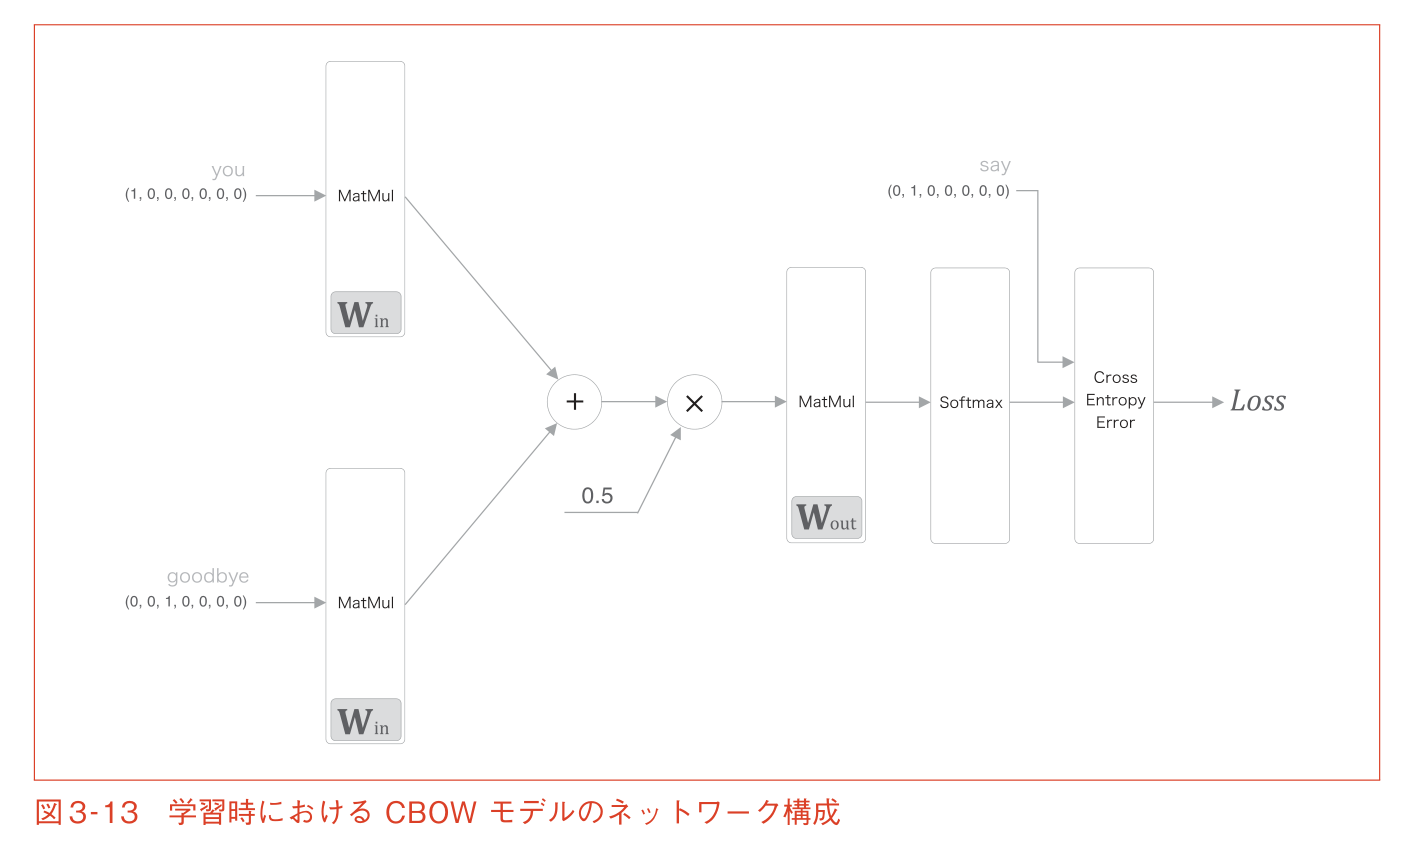

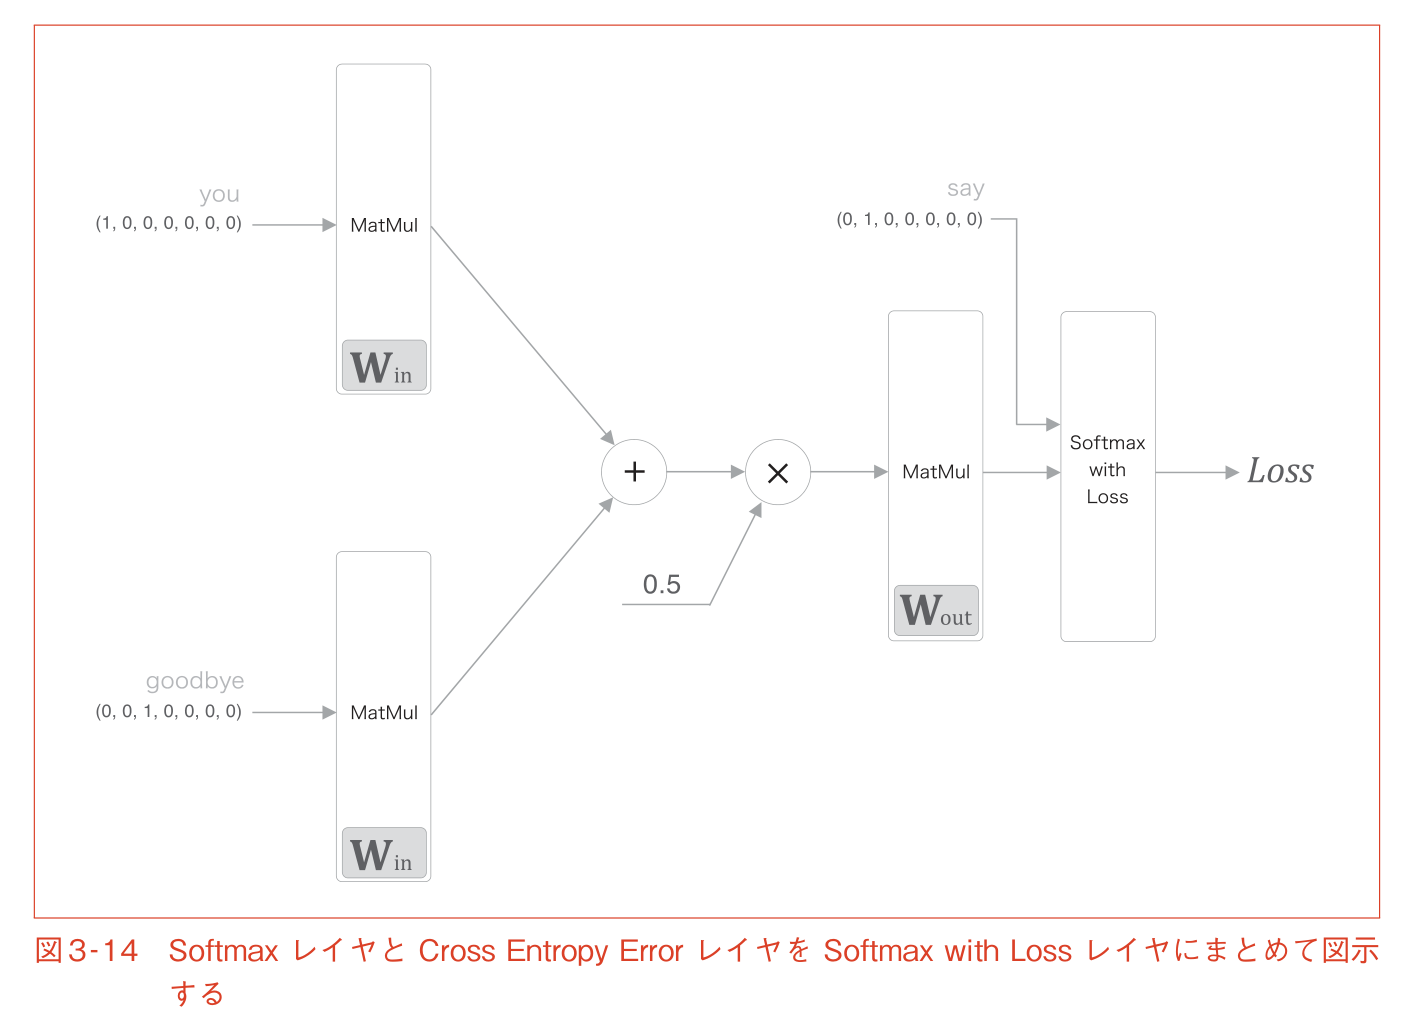

出典: 『ゼロから作るDeep Learning 2』第3章

## 3. 数値で確かめる

語彙7・中間層5・学習率1.0で1000エポック学習した結果

| 段階 | 値 | 読み方 |
|---|---|---|
| epoch 1 | loss = 1.9460 | 7語からの当てずっぽうに近い |
| epoch 200 | loss = 0.2372 | 急速に下がる |
| epoch 1000 | loss = 0.2316 | ほぼ収束 |
| 予測の正解数 | 6件中5件 | (and, say)->i だけ外す |
| you と hello | 類似度 +1.0000 | 同じ文脈に現れるため一致 |

**結論:** goodbye と i は同じ文脈にしか現れず区別できない。コーパスを増やす必要がある


## 4. コードを一行ずつ読む

| コード | 何をしているか |
|---|---|
| `self.w_in = 0.01 * rng.standard_normal((V, H))` | 小さな乱数で初期化する。0にすると全ての語が同じ更新になる |
| `self.h = 0.5 * (h0 + h1)` | 左右の中間表現を平均する。順序の情報は捨てられる |
| `d_score = (self.probability - self.target) / batch_size` | 予測と正解の差を、バッチ件数で平均する |
| `grad_w_in = contexts[:,0].T @ d_h + contexts[:,1].T @ d_h` | 平均した分、勾配も左右へ半分ずつ配って足し合わせる |

次は上から順に1セルずつ実行します。実行する前に、各セルの出力を予想してください。


### 4-1. 準備

この演習で使うライブラリを読み込む。


In [2]:
from __future__ import annotations

import numpy as np


print('準備完了: NumPyを使ってCBOWを手実装する。')

準備完了: NumPyを使ってCBOWを手実装する。


### 4-2. データと設定

扱う文章や定数を決める。値を変えて結果を比べられる。


In [3]:
TEXT = "You say goodbye and I say hello."


print('使用する文章:', TEXT)

使用する文章: You say goodbye and I say hello.


### 4-3. 関数 preprocess を定義する

文章を単語IDの列と、単語とIDの対応表へ変換する。


In [4]:
def preprocess(text: str) -> tuple[np.ndarray, dict[str, int], dict[int, str]]:
    """文章を単語IDの列と、単語とIDの対応表へ変換する。"""
    text = text.lower().replace(".", " .")
    words = text.split(" ")

    word_to_id: dict[str, int] = {}
    id_to_word: dict[int, str] = {}
    for word in words:
        if word not in word_to_id:
            new_id = len(word_to_id)
            word_to_id[word] = new_id
            id_to_word[new_id] = word

    corpus = np.array([word_to_id[word] for word in words])
    return corpus, word_to_id, id_to_word


print('preprocess: 文章を単語ID列と辞書へ変換する関数を定義した。')

preprocess: 文章を単語ID列と辞書へ変換する関数を定義した。


### 4-4. 関数 create_contexts_target を定義する

中央の単語をターゲット、その両隣をコンテキストとして切り出す。


In [5]:
def create_contexts_target(
    corpus: np.ndarray, window_size: int = 1
) -> tuple[np.ndarray, np.ndarray]:
    """中央の単語をターゲット、その両隣をコンテキストとして切り出す。"""
    target = corpus[window_size:-window_size]
    contexts = []
    for idx in range(window_size, len(corpus) - window_size):
        cs = [
            corpus[idx + offset]
            for offset in range(-window_size, window_size + 1)
            if offset != 0
        ]
        contexts.append(cs)
    return np.array(contexts), np.array(target)


print('create_contexts_target: 周辺語と中心語の学習例を作る関数を定義した。')

create_contexts_target: 周辺語と中心語の学習例を作る関数を定義した。


### 4-5. 関数 convert_one_hot を定義する

単語IDを、その位置だけ1になるベクトルへ変換する。


In [6]:
def convert_one_hot(corpus: np.ndarray, vocab_size: int) -> np.ndarray:
    """単語IDを、その位置だけ1になるベクトルへ変換する。"""
    if corpus.ndim == 1:
        one_hot = np.zeros((corpus.shape[0], vocab_size), dtype=np.float32)
        for idx, word_id in enumerate(corpus):
            one_hot[idx, word_id] = 1
        return one_hot

    one_hot = np.zeros((corpus.shape[0], corpus.shape[1], vocab_size), dtype=np.float32)
    for idx_0, word_ids in enumerate(corpus):
        for idx_1, word_id in enumerate(word_ids):
            one_hot[idx_0, idx_1, word_id] = 1
    return one_hot


print('convert_one_hot: 単語IDをone-hotベクトルへ変換する関数を定義した。')

convert_one_hot: 単語IDをone-hotベクトルへ変換する関数を定義した。


### 4-6. 関数 softmax を定義する

スコアを、合計が1になる確率へ変換する。


In [7]:
def softmax(x: np.ndarray) -> np.ndarray:
    """スコアを、合計が1になる確率へ変換する。"""
    x = x - np.max(x, axis=-1, keepdims=True)
    exp_x = np.exp(x)
    return exp_x / np.sum(exp_x, axis=-1, keepdims=True)


print('softmax: 語彙ごとの得点を確率へ変換する関数を定義した。')

softmax: 語彙ごとの得点を確率へ変換する関数を定義した。


### 4-7. 関数 cross_entropy_error を定義する

正解の単語へ与えた確率が低いほど大きくなる損失を計算する。


In [8]:
def cross_entropy_error(probability: np.ndarray, target: np.ndarray) -> float:
    """正解の単語へ与えた確率が低いほど大きくなる損失を計算する。"""
    batch_size = probability.shape[0]
    # log(0)を避けるため、微小値を足してから対数を取る。
    correct = np.sum(probability * target, axis=1)
    return float(-np.sum(np.log(correct + 1e-7)) / batch_size)


print('cross_entropy_error: 正解語の確率から損失を計算する関数を定義した。')

cross_entropy_error: 正解語の確率から損失を計算する関数を定義した。


### 4-8a. SimpleCBOWのモデル構成図

`SimpleCBOW`は一般的なMLPではない。二つの周辺語を**同じ**`W_in`で埋め込み、平均した後、`W_out`とsoftmaxで中心語を分類する。

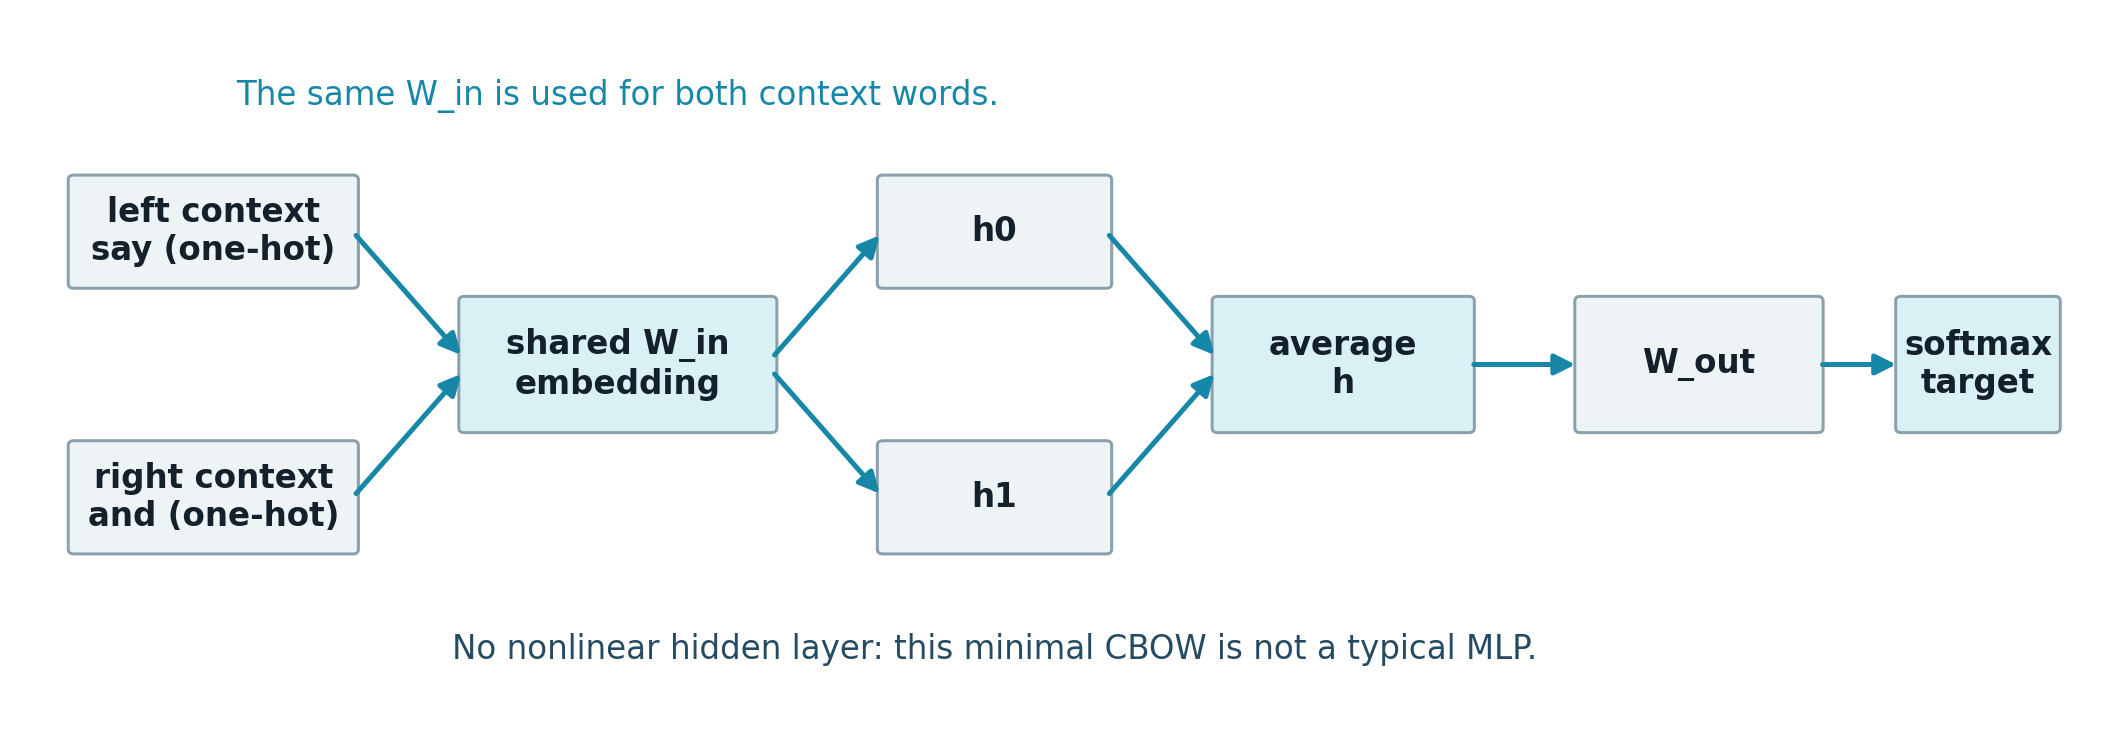

### 4-8. クラス `SimpleCBOW` を定義する

`SimpleCBOW`は、**CBOWモデルに必要な重み・中間結果・学習処理を一つにまとめた部品**である。変数をセルごとにばらばらに置くのではなく、モデル自身が「予測する」「誤差を計算する」「重みを更新する」を担当する。

#### このクラスが保持するもの

| 属性 | 何を保持するか | なぜ必要か |
|---|---|---|
| `w_in` | 語彙数 × 埋め込み次元の入力側重み | 各行が学習後の単語ベクトルになる |
| `w_out` | 埋め込み次元 × 語彙数の出力側重み | 中間表現から語彙ごとの得点を作る |
| `contexts` | 周辺語2語のone-hot入力 | 逆伝播で入力側重みを更新するために保存する |
| `target` | 中心語のone-hot正解ラベル | 予測との差、すなわち誤差を計算するために保存する |
| `h` | 周辺語ベクトルの平均 | `W_out`へ渡す中間表現。CBOWの中心となる値 |
| `probability` | softmax後の語彙ごとの予測確率 | 正解語の確率から損失と勾配を計算する |

#### 四つのメソッド

| メソッド | 入力 | 出力・役割 |
|---|---|---|
| `__init__()` | 語彙数、埋め込み次元 | `w_in`と`w_out`を小さな乱数で初期化する |
| `forward()` | `contexts`, `target` | 予測確率を作り、交差エントロピー損失を返す |
| `backward()` | `forward()`で保存した値 | 損失を小さくする`w_in`・`w_out`の勾配を計算する |
| `update()` | 学習率 | 勾配の反対向きへ重みを少し動かす |

#### 学習時の呼び出し順序

```text
model = SimpleCBOW(...)  →  forward(contexts, target)  →  backward()  →  update(learning_rate)
       重みを用意             予測と損失を作る             勾配を計算       重みを更新
```

この最小実装では、`forward()`が中間結果をクラス内に保存し、次の`backward()`がそれを使う。実務ではPyTorchなどの自動微分ライブラリを使うことが多いが、ここでは逆伝播の意味を確認するためNumPyで明示的に書く。


## 教科書の図: SimpleCBOWの構造と逆伝播

コードの `forward` は図3-19の順伝播、`backward` は図3-20の逆伝播に対応する。損失が下がるかは図3-21のように学習曲線で読む。

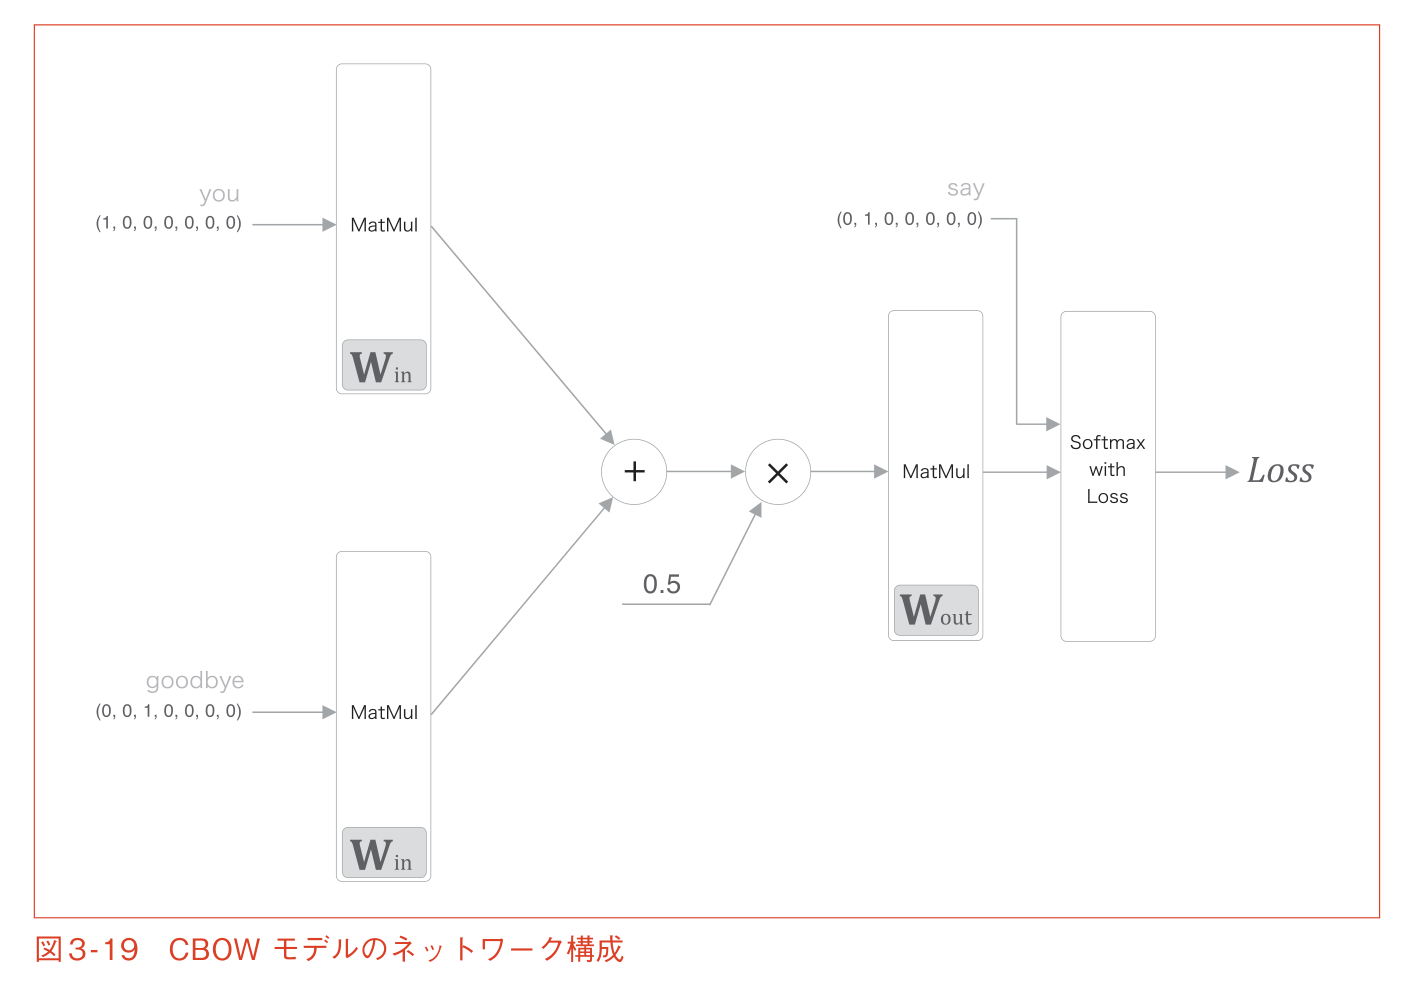

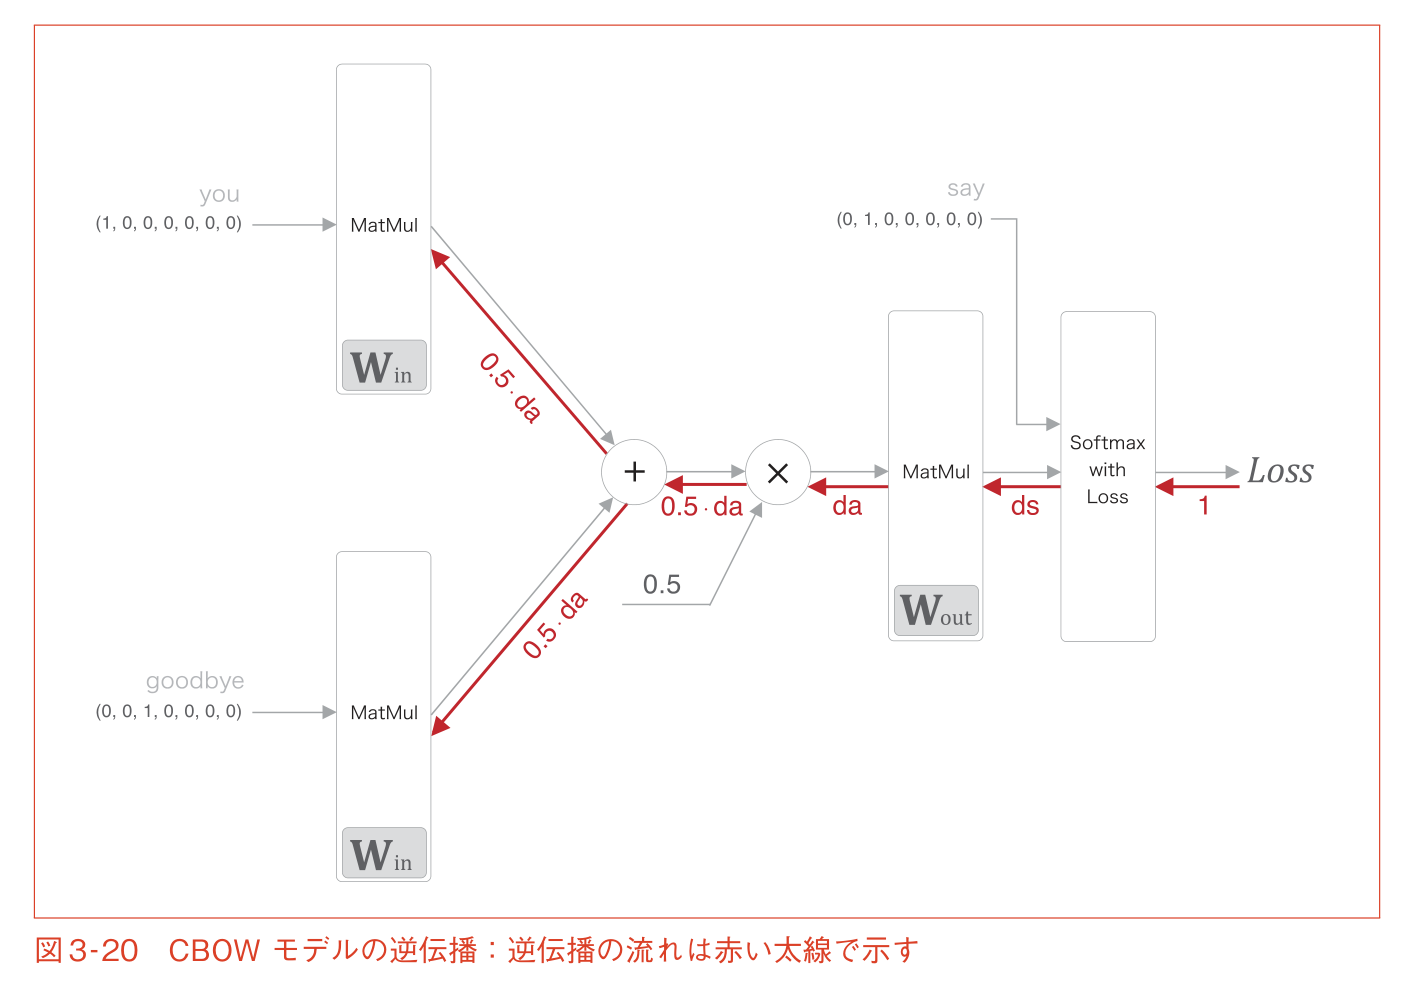

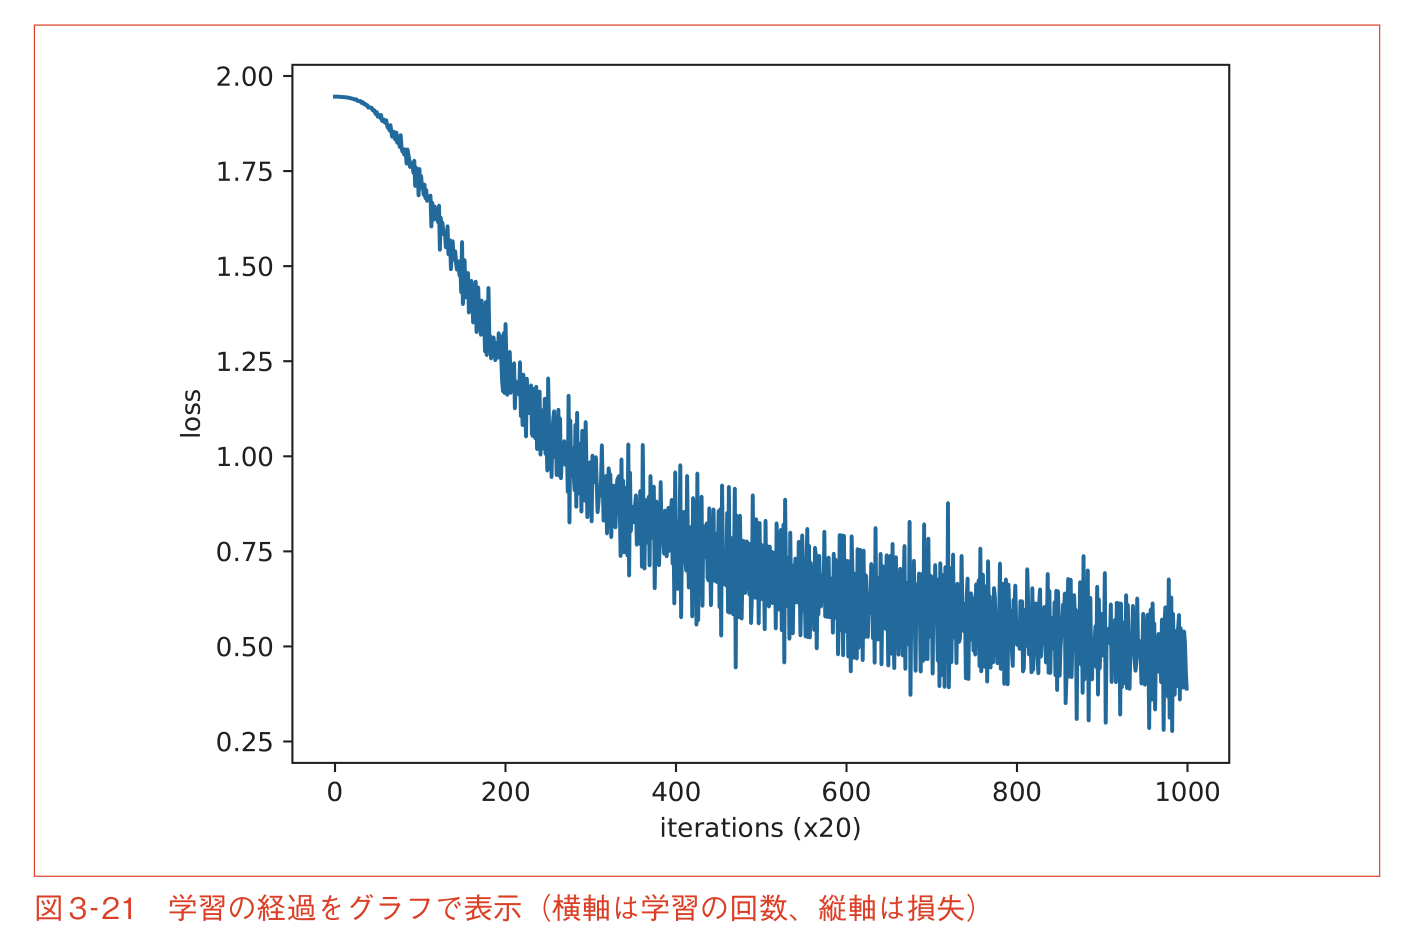

出典: 『ゼロから作るDeep Learning 2』第3章

In [9]:
class SimpleCBOW:
    """両隣の単語から中央の単語を当てる、最小構成のCBOW。"""

    def __init__(self, vocab_size: int, hidden_size: int, seed: int = 1) -> None:
        rng = np.random.default_rng(seed)
        # 入力側の重みが、学習後にそのまま単語の分散表現になる。
        self.w_in = 0.01 * rng.standard_normal((vocab_size, hidden_size)).astype("f")
        self.w_out = 0.01 * rng.standard_normal((hidden_size, vocab_size)).astype("f")

    def forward(self, contexts: np.ndarray, target: np.ndarray) -> float:
        """コンテキストから予測を作り、正解との差を損失として返す。"""
        self.contexts = contexts
        self.target = target
        h0 = contexts[:, 0] @ self.w_in
        h1 = contexts[:, 1] @ self.w_in
        # 左右の中間表現を平均し、位置の違いを区別しない形にまとめる。
        self.h = 0.5 * (h0 + h1)
        score = self.h @ self.w_out
        self.probability = softmax(score)
        return cross_entropy_error(self.probability, target)

    def backward(self) -> tuple[np.ndarray, np.ndarray]:
        """損失を下げる方向、すなわち各重みの勾配を求める。"""
        batch_size = self.contexts.shape[0]
        # softmaxと交差エントロピーを合わせると、勾配は予測と正解の差になる。
        d_score = (self.probability - self.target) / batch_size
        grad_w_out = self.h.T @ d_score
        d_h = d_score @ self.w_out.T
        # 平均でまとめた分、勾配も左右へ半分ずつ配る。
        d_h = d_h * 0.5
        grad_w_in = self.contexts[:, 0].T @ d_h + self.contexts[:, 1].T @ d_h
        return grad_w_in, grad_w_out

    def update(self, learning_rate: float) -> None:
        """勾配の反対方向へ、少しだけ重みを動かす。"""
        grad_w_in, grad_w_out = self.backward()
        self.w_in -= learning_rate * grad_w_in
        self.w_out -= learning_rate * grad_w_out


print('SimpleCBOW: W_in、平均、W_out、softmaxからなるモデルを定義した。')

SimpleCBOW: W_in、平均、W_out、softmaxからなるモデルを定義した。


### 4-9. 関数 cos_similarity を定義する

二つのベクトルの向きの近さを -1 から 1 で返す。


In [ ]:
def cos_similarity(x: np.ndarray, y: np.ndarray, eps: float = 1e-8) -> float:
    """二つのベクトルの向きの近さを -1 から 1 で返す。"""
    nx = x / (np.sqrt(np.sum(x**2)) + eps)
    ny = y / (np.sqrt(np.sum(y**2)) + eps)
    return float(np.dot(nx, ny))


print('cos_similarity: 二つの単語ベクトルの近さを計算する関数を定義した。')

cos_similarity: 二つの単語ベクトルの近さを計算する関数を定義した。


### 4-10. 入力データを作る

CBOWが直接読むのは文章そのものではなく、**周辺語を入力、中心語を正解**にした訓練例である。まず文章を単語ID列 `corpus` に変換し、窓幅1で `(左の語, 右の語) -> 中心語` の組を作る。

例えば `you say goodbye` からは、`(you, goodbye) -> say` という1件が得られる。次に、各単語IDを語彙数7のone-hotベクトルへ変換する。出力の `contexts.shape = (6, 2, 7)` は、**訓練例6件 × 周辺語2個 × 語彙数7** を表し、`target.shape = (6, 7)` は、**各訓練例の正解語を語彙数7で表したもの**である。


In [10]:
import pandas as pd

corpus, word_to_id, id_to_word = preprocess(TEXT)
vocab_size = len(word_to_id)
hidden_size = 5
learning_rate = 1.0
max_epoch = 1000

print('=== 前処理の確認 ===')
print('corpus (単語ID列):', corpus)
print('語彙数:', vocab_size, '  埋め込み次元:', hidden_size)

# まずは、文章がどのように単語IDに変わり、語彙表がどう対応しているかを見る。
# ここが分からないと、後の contexts[0] と target[0] が意味不明になる。
word_to_id_df = pd.DataFrame(
    [{'word': word, 'id': word_id} for word, word_id in word_to_id.items()]
)

print('\nword_to_id (単語 -> ID):')
display(word_to_id_df)

print('\nid_to_word (ID -> 単語):')
display(pd.DataFrame({'id': list(id_to_word.keys()), 'word': list(id_to_word.values())}))


=== 前処理の確認 ===
corpus (単語ID列): [0 1 2 3 4 1 5 6]
語彙数: 7   埋め込み次元: 5

word_to_id (単語 -> ID):


,word,id
0,you,0
1,say,1
2,goodbye,2
3,and,3
4,i,4
5,hello,5
6,.,6



id_to_word (ID -> 単語):


,id,word
0,0,you
1,1,say
2,2,goodbye
3,3,and
4,4,i
5,5,hello
6,6,.


### 4-11. 学習データの1件を読む

`contexts[0]` は最初の訓練例の入力で、2行が左・右の周辺語、各行の長さ7がone-hotベクトルである。値が `1` の位置が、その周辺語の単語IDを示す。`target[0]` は同じ訓練例の正解であり、中心語の位置だけが `1` になる。

この教材では最初の組を **`(you, goodbye) -> say`** として確認する。ここで `word_to_id` の辞書を見れば、`you=0`、`goodbye=2`、`say=3` などのように対応していることが分かる。つまり、周辺語の one-hot で `1` になる位置が、その語の ID になっている。

学習中のモデルは `contexts` から `target` の語を当てるように、`W_in` と `W_out` を更新する。`hidden_size=5` は、各単語を5個の数で表す分散表現の次元数である。


In [11]:
contexts, target = create_contexts_target(corpus, window_size=1)
contexts = convert_one_hot(contexts, vocab_size)
target = convert_one_hot(target, vocab_size)

print('=== 学習データの確認 ===')
print('contexts.shape:', contexts.shape, '  target.shape:', target.shape)
print('\ncontexts[0] (左右の周辺語):')
display(pd.DataFrame(
    contexts[0].astype(int),
    index=['left_context', 'right_context'],
    columns=[f'w{i}' for i in range(vocab_size)],
))
print('\ntarget[0] (中心語):')
display(pd.DataFrame(
    target[0].astype(int).reshape(1, -1),
    index=['target'],
    columns=[f'w{i}' for i in range(vocab_size)],
))


=== 学習データの確認 ===
contexts.shape: (6, 2, 7)   target.shape: (6, 7)

contexts[0] (左右の周辺語):


,w0,w1,w2,w3,w4,w5,w6
left_context,1,0,0,0,0,0,0
right_context,0,0,1,0,0,0,0



target[0] (中心語):


,w0,w1,w2,w3,w4,w5,w6
target,0,1,0,0,0,0,0


### 4-11a. モデルを作る

ここで初めて`SimpleCBOW`のインスタンスを作る。`vocab_size=7`と`hidden_size=5`を渡すと、`W_in`は **(7, 5)**、`W_out`は **(5, 7)** の重み行列として初期化される。

In [12]:
print("=== モデルの定義 ===")
# 語彙数と埋め込み次元を指定し、学習する重み W_in と W_out を用意する。
model = SimpleCBOW(vocab_size, hidden_size)
print("model:", type(model).__name__)
print("W_in.shape :", model.w_in.shape, "（語彙数 × 埋め込み次元）")
print("W_out.shape:", model.w_out.shape, "（埋め込み次元 × 語彙数）")

=== モデルの定義 ===
model: SimpleCBOW
W_in.shape : (7, 5) （語彙数 × 埋め込み次元）
W_out.shape: (5, 7) （埋め込み次元 × 語彙数）


### 4-12. 同じ訓練例を繰り返して重みを更新する

1エポックでは、6件すべての `contexts` をモデルに入力し、予測した確率分布と `target` の正解を比べる。正解語の確率が低いほど損失 `loss` は大きくなる。`forward` は損失と勾配を計算し、`update` は勾配に従って `W_in` と `W_out` を少しずつ更新する。

表示する損失が小さくなるなら、周辺語から中心語を当てるための重みへ近づいている。ただし、このコーパスは6件だけなので、実用的な意味表現を得るための学習ではなく、更新の仕組みを確認するための最小例である。


=== 学習の経過 ===
epoch	loss
1	0.2316
200	0.2315
400	0.2314
600	0.2314
800	0.2313
1000	0.2313


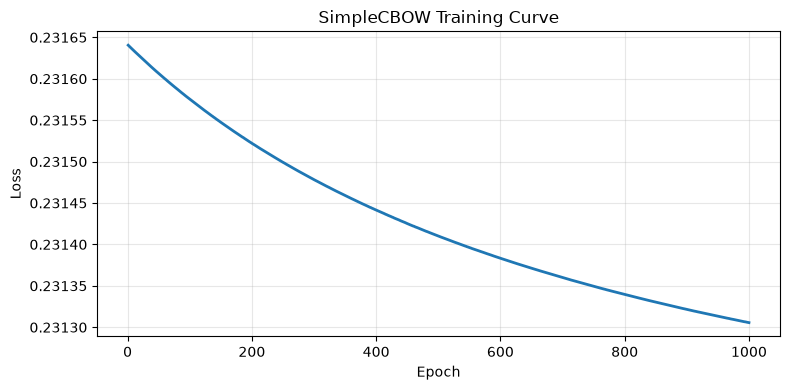

In [14]:
import matplotlib.pyplot as plt

print("=== 学習の経過 ===")
print("epoch\tloss")
epoch_history = []
loss_history = []

for epoch in range(1, max_epoch + 1):
    loss = model.forward(contexts, target)
    model.update(learning_rate)
    epoch_history.append(epoch)
    loss_history.append(loss)
    if epoch == 1 or epoch % 200 == 0:
        print(f"{epoch}\t{loss:.4f}")

plt.figure(figsize=(8, 4))
plt.plot(epoch_history, loss_history, color="tab:blue", linewidth=2)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("SimpleCBOW Training Curve")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 4-13. 周辺語から中心語を予測する

学習後、各訓練例の `contexts` を入力すると、モデルは語彙7語それぞれの確率 `model.probability` を出力する。最大の確率を持つ単語を予測語として、`target` に記録された正解語と比べる。

各行の `(左の語, 右の語) -> 予測 / 正解` を読むことで、CBOWが解こうとしている分類問題を確認できる。丸印が付く行は、その周辺語から中心語を正しく選べた訓練例である。


In [15]:
print("\n=== 学習後の予測 ===")
model.forward(contexts, target)

prediction_rows = []
for i in range(contexts.shape[0]):
    left = id_to_word[int(np.argmax(contexts[i, 0]))]
    right = id_to_word[int(np.argmax(contexts[i, 1]))]
    answer = id_to_word[int(np.argmax(target[i]))]
    predicted = id_to_word[int(np.argmax(model.probability[i]))]
    prediction_rows.append(
        {
            "左の周辺語": left,
            "右の周辺語": right,
            "予測": predicted,
            "正解": answer,
            "判定": "○" if predicted == answer else "×",
        }
    )

prediction_df = pd.DataFrame(prediction_rows)
display(prediction_df)


=== 学習後の予測 ===


,左の周辺語,右の周辺語,予測,正解,判定
0,you,goodbye,say,say,○
1,say,and,goodbye,goodbye,○
2,goodbye,i,and,and,○
3,and,say,goodbye,i,×
4,i,hello,say,say,○
5,say,.,hello,hello,○


### 4-14. `W_in` の各行を単語の分散表現として読む

`W_in` の形は `(語彙数, 埋め込み次元) = (7, 5)` である。したがって、各行は1語に対応し、5個の実数がその語の分散表現になる。one-hotベクトルを `W_in` に掛ける操作は、該当する単語IDの行を取り出す操作と等しい。

ここに表示する数値は、周辺語から中心語を予測する課題を通じて更新された重みである。各数字を単独で解釈するのではなく、**同じ文脈で使われる語ほどベクトル全体が近づく**ことに意味がある。


## 教科書の図: 学習後の重みを単語ベクトルとして読む

入力側・出力側の重みには単語ごとのベクトルが並ぶ。演習では `W_in` の各行を分散表現として取り出し、周辺語から中心語を予測できる形へ学習した結果として読む。

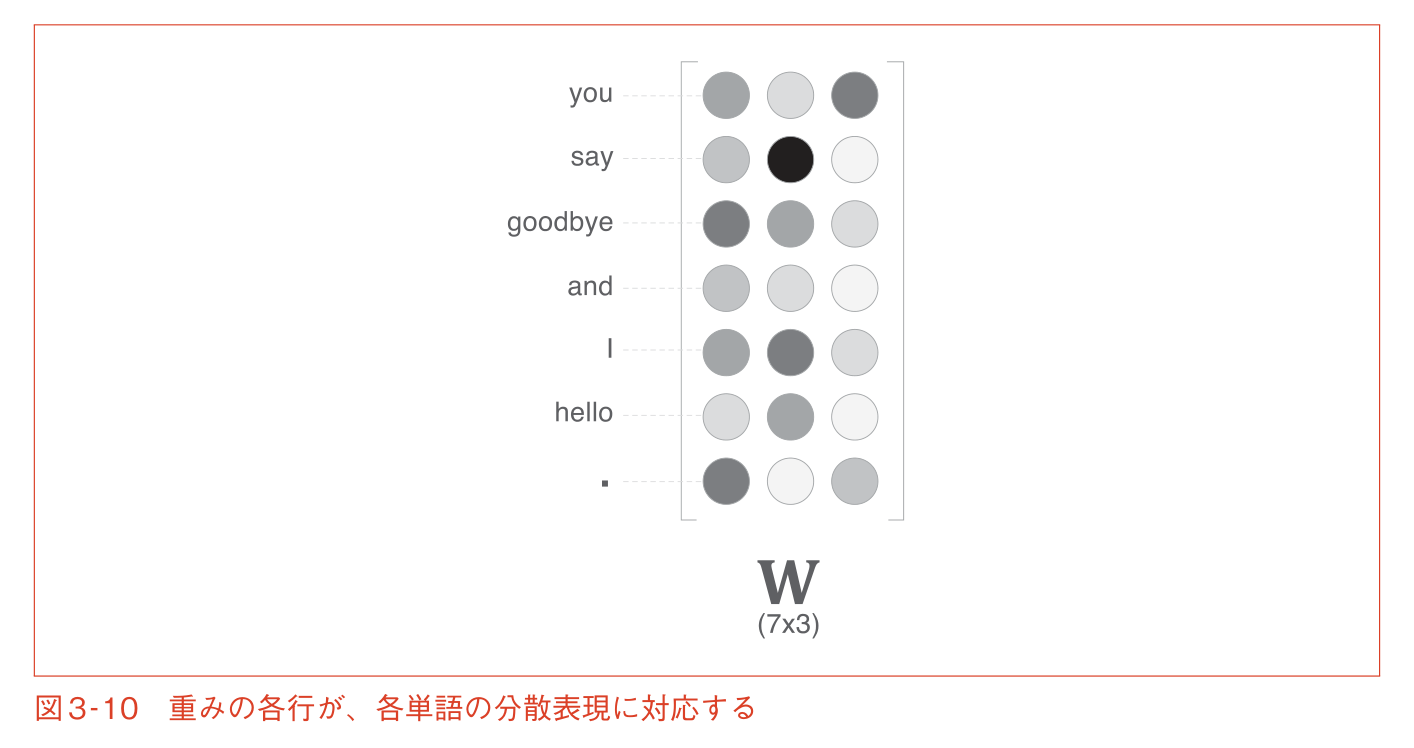

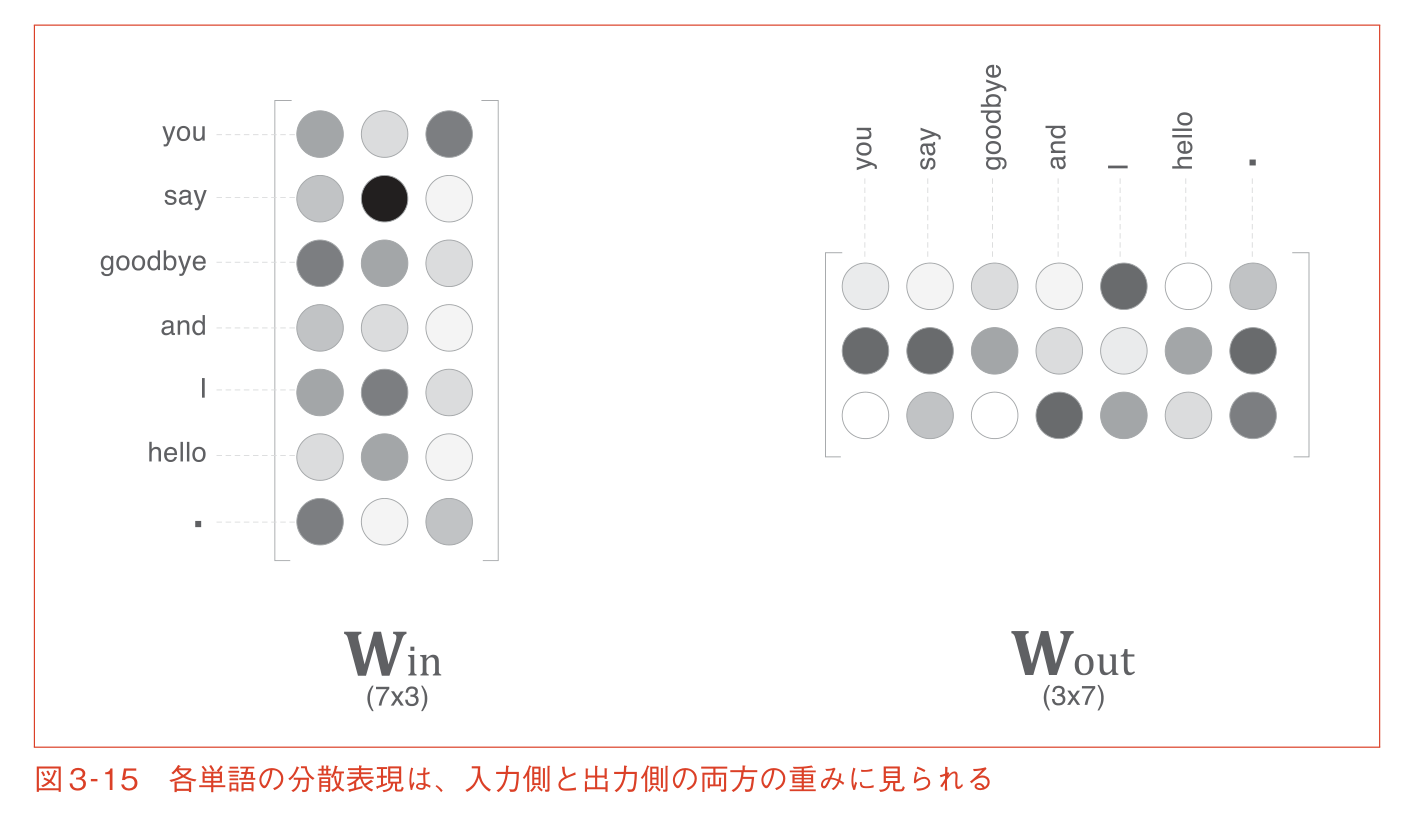

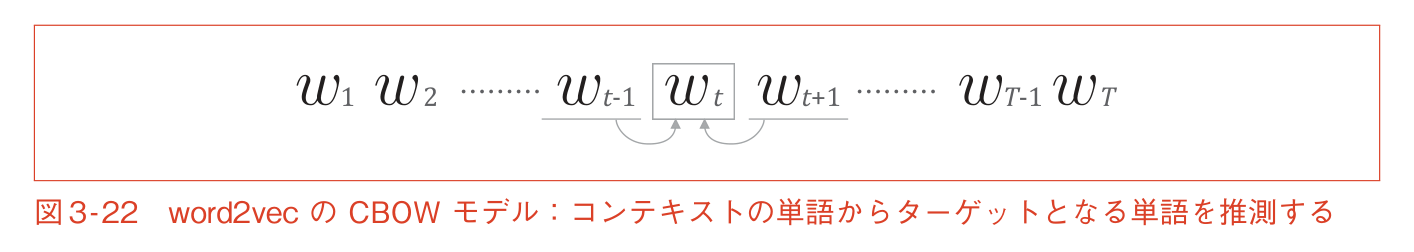

出典: 『ゼロから作るDeep Learning 2』第3章

In [16]:
print('使用する文章:', TEXT)

print("\n=== 得られた単語の分散表現（W_in） ===")
for word_id in range(vocab_size):
    vector = np.round(model.w_in[word_id], 3)
    print(f"{id_to_word[word_id]}\t{vector}")


使用する文章: You say goodbye and I say hello.

=== 得られた単語の分散表現（W_in） ===
you	[-3.297 -0.305  1.805 -0.665 -0.145]
say	[ 1.073 -1.229 -1.78   0.098  1.588]
goodbye	[ 0.766  0.796  1.282  0.634 -1.955]
and	[-0.234  0.399 -2.1   -2.61   1.553]
i	[ 0.773  0.786  1.292  0.644 -1.97 ]
hello	[-3.312 -0.317  1.788 -0.65  -0.144]
.	[ 1.33  -1.633  0.307  2.718  0.035]


### 4-15. ベクトルの向きの近さを比較する

コサイン類似度は、二つの分散表現の向きがどれほど近いかを `-1` から `1` 付近の値で表す。`1` に近いほど似た文脈で現れ、`0` 付近なら関係が弱く、負なら反対向きである。

ここでは3組の語について `W_in` のベクトルを比較する。ただし、学習に使った文は極端に短いため、結果は言葉一般の意味の近さではなく、この6件の訓練例で共有した文脈を反映する。最後の注意書きと合わせて、コーパスの量と多様性が分散表現の質を左右することを確認する。


In [ ]:
print("\n=== 分散表現どうしの類似度 ===")
for left, right in [("you", "hello"), ("goodbye", "i"), ("say", "goodbye")]:
    similarity = cos_similarity(model.w_in[word_to_id[left]], model.w_in[word_to_id[right]])
    print(f"{left} と {right}: {similarity:+.4f}")

print(
    "\n注意: この例文では goodbye と i が同じコンテキストにしか現れないため、"
    "分散表現がほぼ一致し、予測を取り違える。区別するにはコーパスを増やす。"
)



=== 分散表現どうしの類似度 ===
you と hello: +1.0000
goodbye と i: +1.0000
say と goodbye: -0.7134

注意: この例文では goodbye と i が同じコンテキストにしか現れないため、分散表現がほぼ一致し、予測を取り違える。区別するにはコーパスを増やす。


## 5. 出力の読み方

**確認すること**

- 各変数のshapeを記録する
- 学習前後の損失を比較する
- W_inの一行が一語の表現であると確認する

**誤解しやすい点**

- One-hot版とEmbedding版を混同しない
- 平均時に周辺語数で割る
- targetの形式を損失層と合わせる


## 6. どこで使われているか

| 場面 | 使い方 |
|---|---|
| 単語の類似検索 | 学習したW_inを使い、ある語に近い語を探す |
| 語の演算 | king - man + woman のような、意味のベクトル演算を試せる |
| 特徴量としての利用 | 文書分類の入力に、単語ベクトルの平均を使う |
| 未知語への対処 | 学習コーパスに無い語はベクトルを持てない。この限界の確認 |



## 次回へ

予測方向を反転したSkip-gramを実装する

確認演習は別ファイル `../演習/10_simple_cbow_exercise.ipynb` で行います。
